In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("C:/Users/Sharath/Desktop/DataScience Intern/Task3/raw_dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
0,1,0,3,male,22.0,7.25,S
1,2,1,1,female,38.0,71.28,C
2,3,1,3,female,26.0,7.92,S
3,4,1,1,female,35.0,53.10,S
4,5,0,3,male,35.0,8.05,S


In [6]:
print("Shape:", df.shape)
df.info()

Shape: (20, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  20 non-null     int64  
 1   Survived     20 non-null     int64  
 2   Pclass       20 non-null     int64  
 3   Sex          20 non-null     object 
 4   Age          18 non-null     float64
 5   Fare         20 non-null     float64
 6   Embarked     20 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 1.2+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,Fare
count,20.00000,20.000000,20.000000,18.000000,20.000000
mean,10.50000,0.500000,2.250000,30.944444,28.157500
std,5.91608,0.512989,0.910465,13.739048,26.775165
min,1.00000,0.000000,1.000000,2.000000,7.220000
25%,5.75000,0.000000,1.000000,22.500000,7.915000
50%,10.50000,0.500000,3.000000,31.000000,12.065000
75%,15.25000,1.000000,3.000000,37.500000,51.895000
max,20.00000,1.000000,3.000000,58.000000,83.150000


In [8]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            2
Fare           0
Embarked       0
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

PassengerId     0.0
Survived        0.0
Pclass          0.0
Sex             0.0
Age            10.0
Fare            0.0
Embarked        0.0
dtype: float64


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

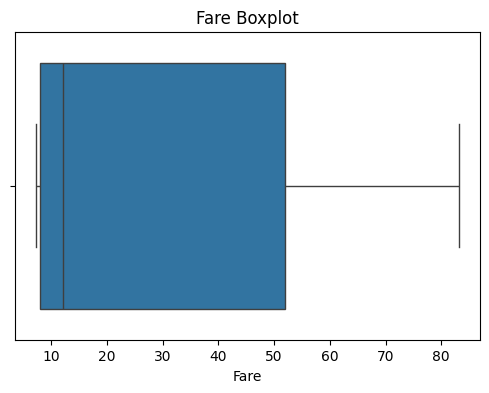

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])
plt.title("Fare Boxplot")
plt.show()

In [13]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]

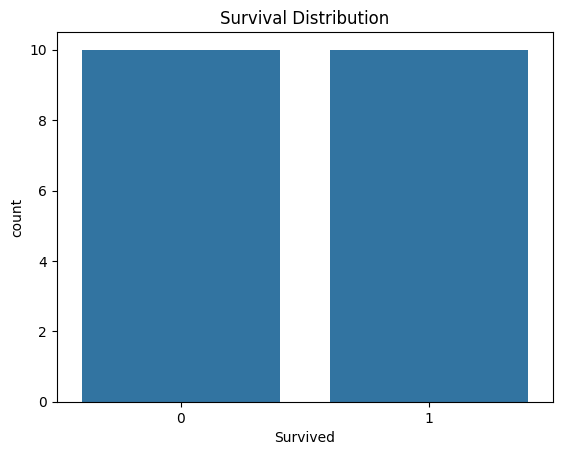

In [14]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

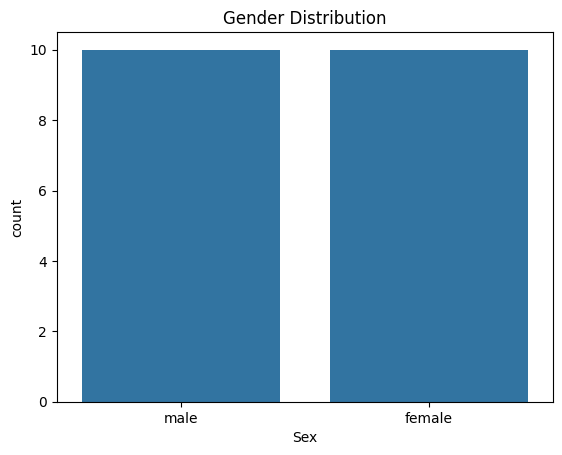

In [15]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

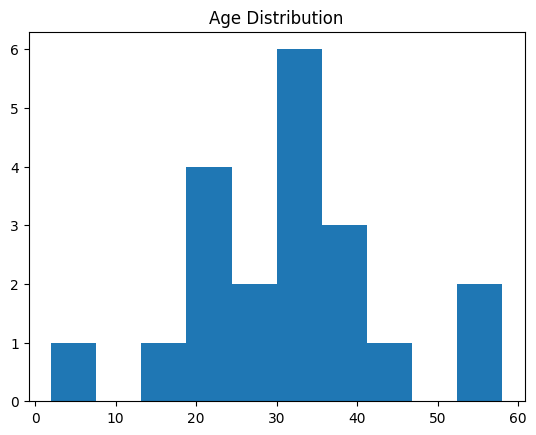

In [16]:
plt.hist(df['Age'], bins=10)
plt.title("Age Distribution")
plt.show()

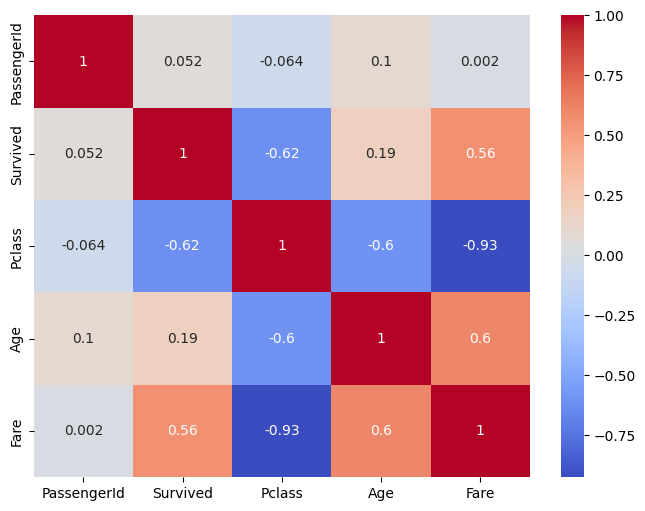

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [19]:
df.to_csv("C:/Users/Sharath/Desktop/DataScience Intern/Task3/cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
